In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.8 MB/s eta 0:00:00


In [2]:
from gensim.models import Word2Vec

# Mini court document dataset (anonymized, JurisAI theme)
sentences = [
    ["the", "court", "delivered", "judgment", "in", "favor", "of", "the", "plaintiff"],
    ["the", "defendant", "filed", "an", "appeal", "against", "the", "ruling"],
    ["the", "judge", "presided", "over", "the", "case", "in", "the", "high", "court"],
    ["the", "lawyer", "presented", "evidence", "to", "support", "the", "claim"],
    ["the", "plaintiff", "sought", "compensation", "for", "damages"],
    ["the", "defendant", "denied", "the", "allegations", "in", "court"],
    ["the", "magistrate", "issued", "a", "ruling", "on", "the", "bail", "application"],
    ["the", "court", "of", "appeal", "reviewed", "the", "judgment"],
]

model = Word2Vec(sentences, vector_size=50, window=2, min_count=1)

print(model.wv["court"])

[-0.01630512  0.00897333 -0.00827457  0.00165644  0.01698503 -0.00892865
  0.0090431  -0.01355186 -0.00709489  0.01878962 -0.00315638  0.00064835
 -0.00827248 -0.01534951 -0.00302039  0.00495446 -0.00176357  0.01108851
 -0.00548412  0.00451827  0.01092196  0.0166795  -0.00289071 -0.01840601
  0.00874655  0.0011425   0.01486405 -0.00160964 -0.00528252 -0.01751638
 -0.00172216  0.0056591   0.01081454  0.014099   -0.01139158  0.00371745
  0.01218976 -0.0095933  -0.00621014  0.01358799  0.00327376  0.00036689
  0.00693907  0.00044728  0.01924838  0.01012848 -0.01783653 -0.01408407
  0.00181763  0.01277961]


In [3]:
print(model.wv.most_similar("court"))

[('over', 0.37591585516929626), ('allegations', 0.2296336144208908), ('high', 0.22094985842704773), ('evidence', 0.21917426586151123), ('against', 0.19461973011493683), ('for', 0.160485178232193), ('damages', 0.14895139634609222), ('appeal', 0.12480459362268448), ('judge', 0.11079093813896179), ('presided', 0.09325646609067917)]


In [4]:
print(model.wv.similarity("court", "judge"))

0.110790916


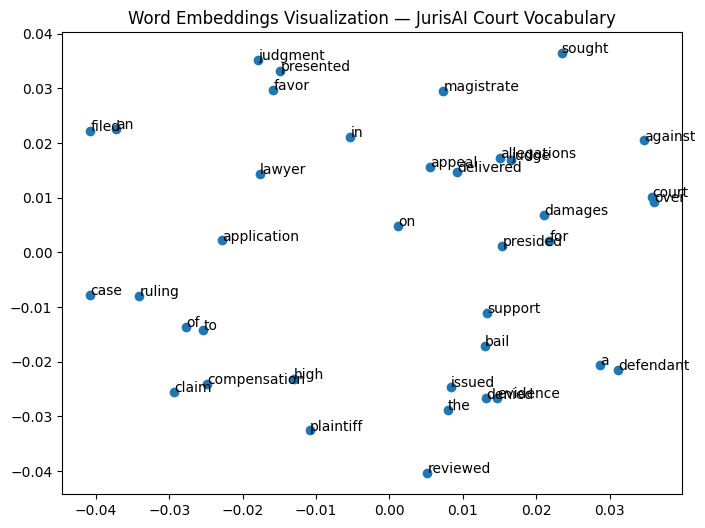

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = list(model.wv.index_to_key)
vectors = model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8, 6))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word Embeddings Visualization — JurisAI Court Vocabulary")
plt.show()

In [6]:
# One-Hot Encoding
words_demo = ["cat", "dog", "animal"]
one_hot = {
    "cat":    [1, 0, 0],
    "dog":    [0, 1, 0],
    "animal": [0, 0, 1],
}

print("ONE-HOT ENCODING")
for w in words_demo:
    print(w, "->", one_hot[w])

# Word Embeddings (train a tiny model)
demo_sentences = [
    ["the", "cat", "is", "an", "animal"],
    ["the", "dog", "is", "an", "animal"],
    ["cats", "and", "dogs", "are", "animals"],
]
demo_model = Word2Vec(demo_sentences, vector_size=10, window=2, min_count=1)

print("\nWORD EMBEDDINGS")
for w in words_demo:
    print(w, "->", demo_model.wv[w])

ONE-HOT ENCODING
cat -> [1, 0, 0]
dog -> [0, 1, 0]
animal -> [0, 0, 1]

WORD EMBEDDINGS
cat -> [-0.08619688  0.03665738  0.05189884  0.05741938  0.07466918 -0.06167675
  0.01105614  0.06047282 -0.0284005  -0.06173522]
dog -> [ 0.01631486  0.00189918  0.03473659  0.00217779  0.09618887  0.05060635
 -0.08917446 -0.07041604  0.00901462  0.06392574]
animal -> [-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]


In [7]:
print("Most similar to 'court':", model.wv.most_similar("court", topn=3))
print("Most similar to 'judge':", model.wv.most_similar("judge", topn=3))
print("Similarity (court, judgment):", model.wv.similarity("court", "judgment"))
print("Similarity (plaintiff, defendant):", model.wv.similarity("plaintiff", "defendant"))

Most similar to 'court': [('over', 0.37591585516929626), ('allegations', 0.2296336144208908), ('high', 0.22094985842704773)]
Most similar to 'judge': [('magistrate', 0.317442923784256), ('the', 0.24099932610988617), ('judgment', 0.21848328411579132)]
Similarity (court, judgment): -0.118897505
Similarity (plaintiff, defendant): 0.18350084


In [8]:
# Larger JurisAI court dataset
court_sentences = [
    ["the", "court", "delivered", "judgment", "in", "favor", "of", "the", "plaintiff"],
    ["the", "defendant", "filed", "an", "appeal", "against", "the", "ruling"],
    ["the", "judge", "presided", "over", "the", "case", "in", "the", "high", "court"],
    ["the", "lawyer", "presented", "evidence", "to", "support", "the", "claim"],
    ["the", "plaintiff", "sought", "compensation", "for", "damages"],
    ["the", "defendant", "denied", "the", "allegations", "in", "court"],
    ["the", "magistrate", "issued", "a", "ruling", "on", "the", "bail", "application"],
    ["the", "court", "of", "appeal", "reviewed", "the", "judgment"],
    ["the", "witness", "gave", "testimony", "before", "the", "court"],
    ["the", "prosecution", "presented", "evidence", "against", "the", "accused"],
]

task_model = Word2Vec(court_sentences, vector_size=50, window=3, min_count=1)

# Display word vectors
print("Vector for 'judgment':\n", task_model.wv["judgment"])

# Find similar words
print("\nWords similar to 'judgment':", task_model.wv.most_similar("judgment"))

Vector for 'judgment':
 [ 0.00548581 -0.01672303  0.01570105  0.01707505 -0.01918048  0.00488352
  0.01981441 -0.01529837 -0.01392974 -0.01549039  0.01679975 -0.00135718
  0.01829535 -0.01630989  0.00748325  0.00527076  0.00149413  0.00466503
 -0.01495373 -0.01874328  0.0047214   0.01229494  0.01598727  0.01148686
 -0.00154614  0.01660576 -0.01868441  0.00683496  0.00051576  0.00771211
  0.01476815 -0.01345261  0.01117412 -0.01904356 -0.00160931 -0.01736982
 -0.01017501  0.01857843 -0.00372331  0.00581489  0.01814041  0.01786949
 -0.01643045 -0.00602552  0.01979269  0.01021299 -0.00317167 -0.01738671
  0.00592761 -0.01334228]

Words similar to 'judgment': [('before', 0.5294206142425537), ('issued', 0.3066961169242859), ('presided', 0.2894638776779175), ('gave', 0.22577008605003357), ('ruling', 0.19794319570064545), ('prosecution', 0.19164973497390747), ('accused', 0.17534150183200836), ('the', 0.16856202483177185), ('in', 0.15557992458343506), ('filed', 0.15488465130329132)]


In [9]:
legal_words = ["court", "judge", "plaintiff", "defendant", "appeal",
               "judgment", "evidence", "ruling", "lawyer", "case"]

print("SIMILARITY ANALYSIS — 10 LEGAL TERMS")
print("=" * 50)

for word in legal_words:
    if word in task_model.wv:
        similar = task_model.wv.most_similar(word, topn=3)
        print(f"\n{word.upper()}")
        for sim_word, score in similar:
            print(f"   {sim_word}: {score:.3f}")

SIMILARITY ANALYSIS — 10 LEGAL TERMS

COURT
   sought: 0.376
   gave: 0.230
   for: 0.221

JUDGE
   support: 0.275
   compensation: 0.240
   an: 0.215

PLAINTIFF
   for: 0.264
   delivered: 0.254
   favor: 0.235

DEFENDANT
   denied: 0.316
   of: 0.237
   support: 0.219

APPEAL
   over: 0.242
   defendant: 0.185
   a: 0.171

JUDGMENT
   before: 0.529
   issued: 0.307
   presided: 0.289

EVIDENCE
   magistrate: 0.228
   favor: 0.211
   compensation: 0.203

RULING
   prosecution: 0.307
   witness: 0.271
   plaintiff: 0.225

LAWYER
   case: 0.286
   compensation: 0.270
   high: 0.214

CASE
   lawyer: 0.286
   in: 0.251
   reviewed: 0.192


Words similar to 'judge': [('delivered', 0.30163827538490295), ('court', 0.22998546063899994), ('magistrate', 0.22650815546512604), ('favor', 0.20115205645561218), ('upheld', 0.17838779091835022), ('filed', 0.1652655303478241), ('presided', 0.1494046300649643), ('on', 0.1413596123456955), ('testimony', 0.1373540759086609), ('granted', 0.13663701713085175)]
Words similar to 'appeal': [('reviewed', 0.2525217831134796), ('gave', 0.24840110540390015), ('for', 0.20062749087810516), ('against', 0.19774965941905975), ('claim', 0.18121075630187988), ('judgment', 0.16845782101154327), ('magistrate', 0.15574553608894348), ('damages', 0.15122418105602264), ('high', 0.14507174491882324), ('read', 0.14418457448482513)]


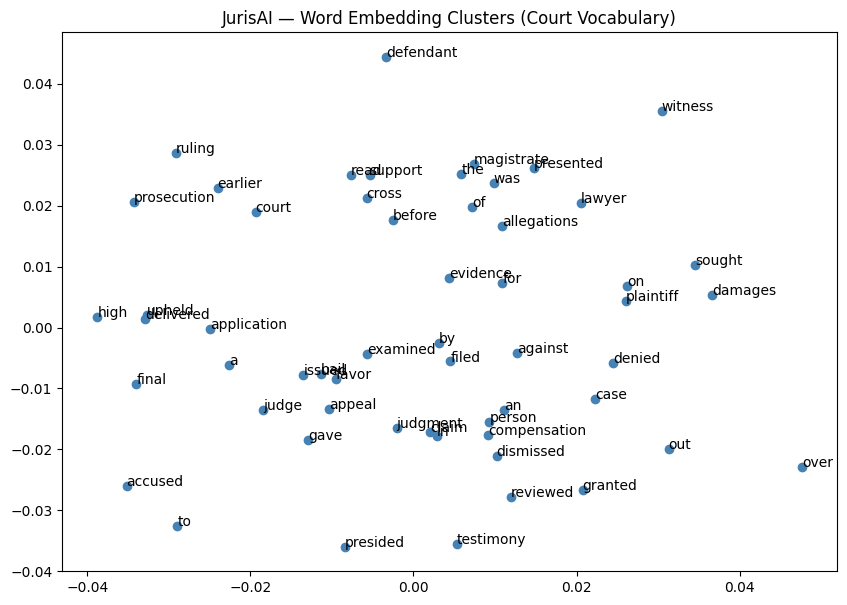

In [10]:
# Bigger anonymized court dataset
advanced_sentences = court_sentences + [
    ["the", "court", "of", "appeal", "upheld", "the", "earlier", "judgment"],
    ["the", "accused", "person", "was", "granted", "bail", "by", "the", "magistrate"],
    ["the", "high", "court", "dismissed", "the", "appeal", "filed", "by", "the", "defendant"],
    ["the", "lawyer", "cross", "examined", "the", "witness", "in", "court"],
    ["the", "judge", "read", "out", "the", "final", "judgment"],
]

advanced_model = Word2Vec(advanced_sentences, vector_size=50, window=3, min_count=1)

# Semantic relationships
print("Words similar to 'judge':", advanced_model.wv.most_similar("judge"))
print("Words similar to 'appeal':", advanced_model.wv.most_similar("appeal"))

# Visualize clusters
words = list(advanced_model.wv.index_to_key)
vectors = advanced_model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))
plt.scatter(result[:, 0], result[:, 1], color="steelblue")
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title("JurisAI — Word Embedding Clusters (Court Vocabulary)")
plt.show()